CLUSTERING ANALYSIS 

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [53]:
#loading the dataset
df=pd.read_excel("EastWestAirlines.xlsx",sheet_name="data")

In [ ]:
df.shape

In [5]:
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [54]:
# Drop ID column 
data=df.drop(columns=["ID#"]) #Removed non-informative column

In [9]:
data.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,28143,0,1,1,1,174,1,0,0,7000,0
1,19244,0,1,1,1,215,2,0,0,6968,0
2,41354,0,1,1,1,4123,4,0,0,7034,0
3,14776,0,1,1,1,500,1,0,0,6952,0
4,97752,0,4,1,1,43300,26,2077,4,6935,1


In [10]:
data.tail()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
3994,18476,0,1,1,1,8525,4,200,1,1403,1
3995,64385,0,1,1,1,981,5,0,0,1395,1
3996,73597,0,3,1,1,25447,8,0,0,1402,1
3997,54899,0,1,1,1,500,1,500,1,1401,0
3998,3016,0,1,1,1,0,0,0,0,1398,0


In [11]:
# Check missing values
df.isnull().sum()

ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64

In [12]:
# Checking for duplicates
df.duplicated().sum()

np.int64(0)

In [55]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
std_sca=StandardScaler()

In [56]:
data[['Balance','Qual_miles','cc1_miles','cc2_miles','cc3_miles','Bonus_miles','Bonus_trans','Flight_miles_12mo','Flight_trans_12','Days_since_enroll']]= std_sca.fit_transform(data[['Balance','Qual_miles','cc1_miles','cc2_miles','cc3_miles','Bonus_miles','Bonus_trans','Flight_miles_12mo','Flight_trans_12','Days_since_enroll']])

In [19]:
data

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,-0.451141,-0.186299,-0.769578,-0.098242,-0.062767,-0.702786,-1.104065,-0.328603,-0.362168,1.395454,0
1,-0.539457,-0.186299,-0.769578,-0.098242,-0.062767,-0.701088,-0.999926,-0.328603,-0.362168,1.379957,0
2,-0.320031,-0.186299,-0.769578,-0.098242,-0.062767,-0.539253,-0.791649,-0.328603,-0.362168,1.411920,0
3,-0.583799,-0.186299,-0.769578,-0.098242,-0.062767,-0.689286,-1.104065,-0.328603,-0.362168,1.372208,0
4,0.239678,-0.186299,1.409471,-0.098242,-0.062767,1.083121,1.499394,1.154932,0.692490,1.363975,1
...,...,...,...,...,...,...,...,...,...,...,...
3994,-0.547079,-0.186299,-0.769578,-0.098242,-0.062767,-0.356960,-0.791649,-0.185750,-0.098503,-1.315120,1
3995,-0.091465,-0.186299,-0.769578,-0.098242,-0.062767,-0.669367,-0.687511,-0.328603,-0.362168,-1.318994,1
3996,-0.000043,-0.186299,0.683121,-0.098242,-0.062767,0.343804,-0.375096,-0.328603,-0.362168,-1.315604,1
3997,-0.185607,-0.186299,-0.769578,-0.098242,-0.062767,-0.689286,-1.104065,0.028531,-0.098503,-1.316088,0


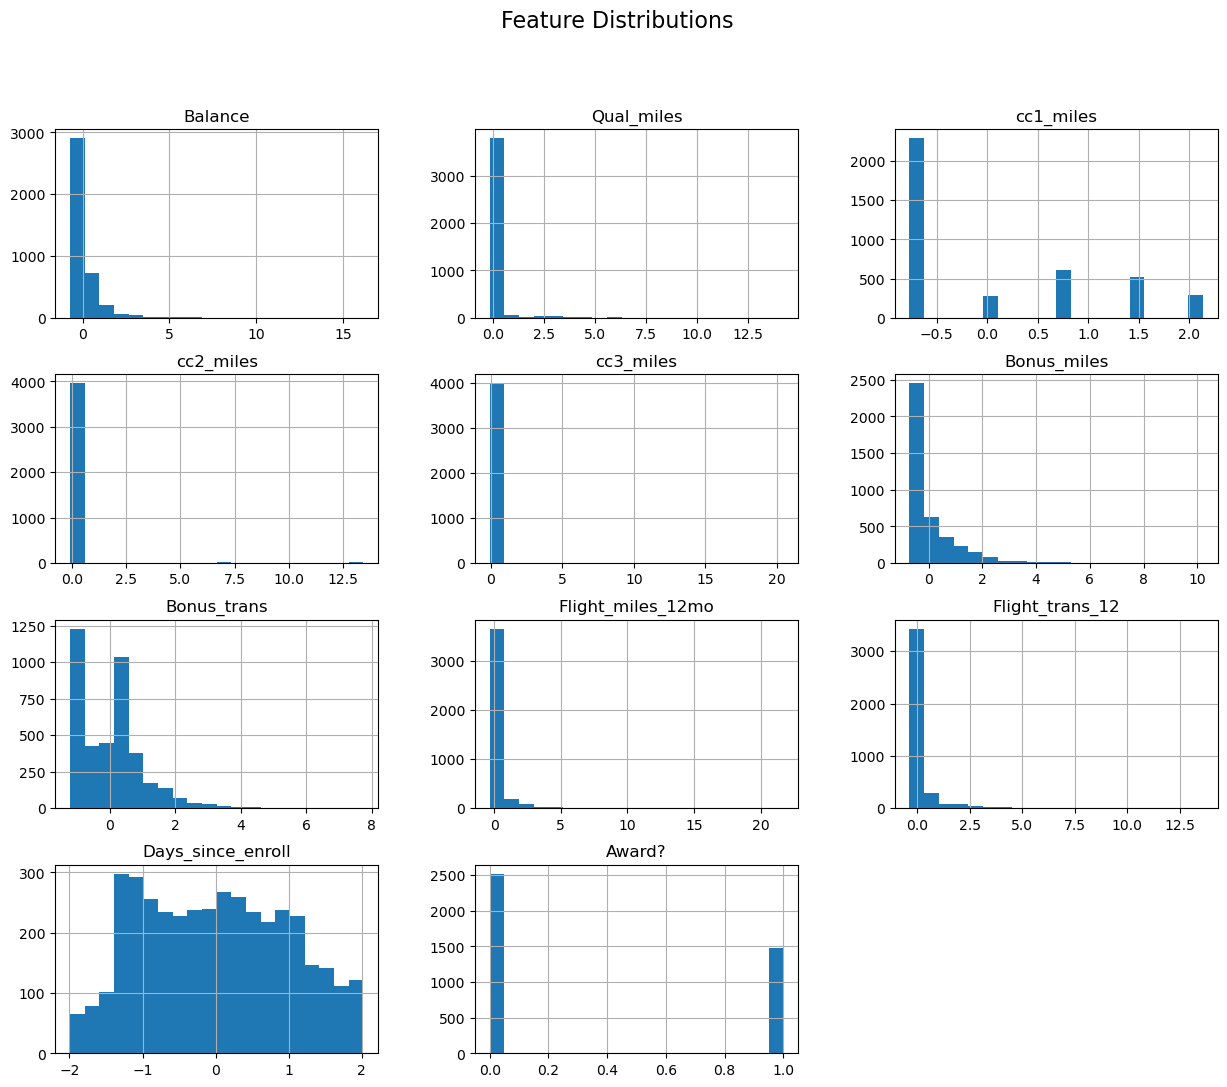

In [22]:
data.hist(figsize=(15,12), bins=20)
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()

In [ ]:
Interpretation:
Many customers have low flight activity

A small group of customers are high-value frequent flyers

Clear potential for customer segmentation

In [57]:
from sklearn.cluster import KMeans

In [58]:
kmeans=KMeans(n_clusters=3) # number of clusters=3
clusters=kmeans.fit(data)

In [9]:
np.unique(clusters.labels_) # shows clusters =0,1,2

array([0, 1, 2], dtype=int32)

In [59]:
data['cluster']= clusters.labels_

In [28]:
data.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,cluster
0,-0.451141,-0.186299,-0.769578,-0.098242,-0.062767,-0.702786,-1.104065,-0.328603,-0.362168,1.395454,0,0
1,-0.539457,-0.186299,-0.769578,-0.098242,-0.062767,-0.701088,-0.999926,-0.328603,-0.362168,1.379957,0,0
2,-0.320031,-0.186299,-0.769578,-0.098242,-0.062767,-0.539253,-0.791649,-0.328603,-0.362168,1.411920,0,0
3,-0.583799,-0.186299,-0.769578,-0.098242,-0.062767,-0.689286,-1.104065,-0.328603,-0.362168,1.372208,0,0
4,0.239678,-0.186299,1.409471,-0.098242,-0.062767,1.083121,1.499394,1.154932,0.692490,1.363975,1,2


In [60]:
#Silhouette Score :Measures how well data points fit within their clusters.
from sklearn.metrics import silhouette_score
silhouette_score(data,clusters.labels_)

np.float64(0.34572639556711054)

In [61]:
kmeans.inertia_

28371.669763265272

In [62]:
### Elbow curve
inertia=[]
for i in range(1,11):
  kmeans= KMeans(n_clusters=i)
  kmeans.fit(data)
  inertia.append(kmeans.inertia_)
print(inertia)

[42241.3813453364, 33211.45312973385, 28494.557293698555, 26540.856426380247, 23121.34349106915, 20226.284004362467, 17894.02273450523, 17442.031943606726, 14945.896324371188, 13265.938835729206]


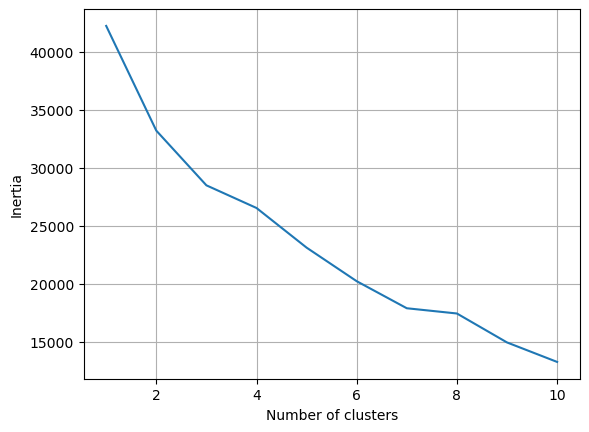

In [63]:
plt.plot(range(1,11),inertia)
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.grid()

In [40]:
kmeans=KMeans(n_clusters=4)
clusters=kmeans.fit(data)

In [41]:
silhouette_score(data,clusters.labels_)

np.float64(0.40499456750271784)

In [64]:
from sklearn.cluster import DBSCAN

In [77]:
dbscan = DBSCAN(eps=1, min_samples=5)
labels_db = dbscan.fit_predict(data)
sil_dbscan = silhouette_score(data, labels_db)
sil_dbscan

np.float64(0.08216710422514098)

In [ ]:
•	Experiment with different parameter settings for DBSCAN (e.g., epsilon, minPts)

In [65]:
#finding nearest neigh
from sklearn.neighbors import NearestNeighbors
nn= NearestNeighbors(n_neighbors=20).fit(data)

In [66]:
distance,index=nn.kneighbors(data)
distance.shape

(3999, 20)

In [67]:
distance1=np.sort(distance,axis=0) # sorting

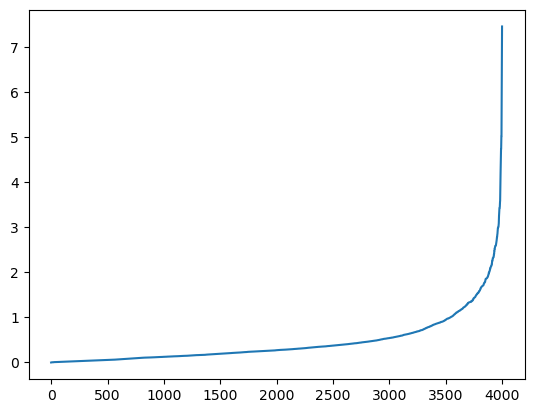

In [68]:
data1=distance1[:,1] 
plt.plot(data1)

In [69]:
# Range of eps and min_mode values
eps=[0.75,1,1.2,1.3,1.4,1.5,1.6]
min_node=range(2,12)

In [71]:
output=[]
for i in eps:
  for j in min_node:
    labels=DBSCAN(eps=i,min_samples=j).fit(data).labels_
    score= silhouette_score(data,labels)
    output.append([i,j,score])

In [72]:
print(output)

[[0.75, 2, np.float64(-0.19098760795792932)], [0.75, 3, np.float64(-0.06554534731612201)], [0.75, 4, np.float64(-0.022717601514476788)], [0.75, 5, np.float64(-0.007859537039314373)], [0.75, 6, np.float64(-0.0068310550587209725)], [0.75, 7, np.float64(-0.00824219446776071)], [0.75, 8, np.float64(0.0194468480509374)], [0.75, 9, np.float64(0.021039582184299653)], [0.75, 10, np.float64(0.01920199362342219)], [0.75, 11, np.float64(0.02255031077595222)], [1, 2, np.float64(0.022975121283439183)], [1, 3, np.float64(0.07365973802472352)], [1, 4, np.float64(0.07476139198149848)], [1, 5, np.float64(0.08216710422514098)], [1, 6, np.float64(0.09182047350659052)], [1, 7, np.float64(0.08430241003407975)], [1, 8, np.float64(0.08436605060580106)], [1, 9, np.float64(0.08148265627570918)], [1, 10, np.float64(0.07879196151626136)], [1, 11, np.float64(0.07897800037099059)], [1.2, 2, np.float64(0.04850920925748429)], [1.2, 3, np.float64(0.12917070725520355)], [1.2, 4, np.float64(0.15919786475333067)], [1.2,

In [73]:
eps,min_nodes, score=sorted(output,key=lambda x: x[2],reverse=True)[0]

In [74]:
print('eps:',eps,'min_nodes:',min_nodes,'score:',score)

eps: 1.4 min_nodes: 11 score: 0.5252472858062927


In [80]:
labels=DBSCAN(eps=1.4,min_samples=11).fit(data).labels_

In [81]:
np.unique(labels)

array([-1,  0,  1])

In [84]:
np.where(labels<0) #outliers

(array([   8,   21,   22,   24,   42,   43,   45,   50,   63,   65,   70,
          72,   87,   94,  106,  111,  112,  114,  117,  121,  126,  127,
         135,  151,  162,  172,  175,  177,  186,  188,  190,  191,  192,
         193,  198,  201,  210,  220,  226,  238,  243,  244,  245,  256,
         259,  269,  275,  282,  290,  298,  307,  313,  315,  318,  323,
         325,  327,  335,  336,  343,  360,  369,  371,  375,  380,  381,
         383,  384,  392,  404,  410,  412,  418,  419,  420,  423,  427,
         437,  444,  448,  465,  466,  467,  471,  475,  481,  484,  488,
         492,  500,  510,  511,  517,  519,  531,  532,  534,  549,  561,
         589,  594,  608,  611,  622,  624,  629,  630,  650,  652,  662,
         676,  681,  683,  693,  697,  702,  704,  708,  718,  725,  743,
         772,  800,  805,  820,  823,  826,  830,  833,  839,  850,  851,
         860,  864,  868,  891,  896,  901,  904,  905,  914,  917,  940,
         958,  966,  972,  976,  998, 

In [ ]:
Interpretation
Initially with random values:
K-Means performs better on this dataset

DBSCAN finds noise but struggles with high-dimensional airline data

with parameter tuning :
score improved for DBSCAN

In [ ]:

Visualization:


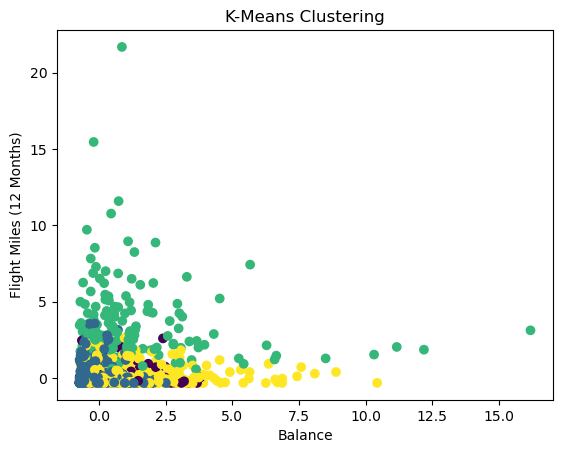

In [89]:
# Apply K-Means
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans_labels = kmeans.fit_predict(data)

# Scatter plot using two original features
plt.figure()
plt.scatter(
    data['Balance'],
    data['Flight_miles_12mo'],
    c=kmeans_labels
)

plt.xlabel("Balance")
plt.ylabel("Flight Miles (12 Months)")
plt.title("K-Means Clustering")
plt.show()

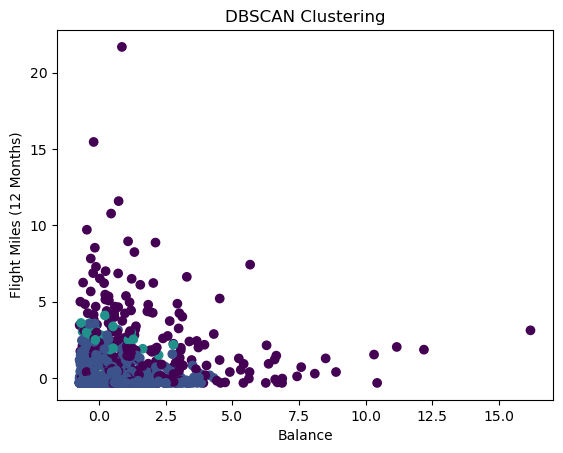

In [88]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
db_labels = dbscan.fit_predict(data)

# Scatter plot using two original features
plt.figure()
plt.scatter(
    data['Balance'],
    data['Flight_miles_12mo'],
    c=db_labels
)

plt.xlabel("Balance")
plt.ylabel("Flight Miles (12 Months)")
plt.title("DBSCAN Clustering")
plt.show()